In [1]:
# imports
import os
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")

from pydantic import BaseModel, Field
from langchain.tools import BaseTool, StructuredTool, tool
from langchain_openai import ChatOpenAI
from langchain.agents import AgentExecutor,create_react_agent,create_openai_functions_agent # To load simple ReAct agent. Reason an act
from langchain import hub
from langchain_ollama.llms import OllamaLLM
from langchain_ollama import ChatOllama
from langchain.chat_models import init_chat_model
##Define API key for OPenAI
from langchain.chat_models import ChatOpenAI
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")


### Use DynaMate Template to convert functions into agent-usable tools 

#### Define class for description of inputs in structured tool 
```bash
### Define inputs in a class
class HelloWorld_inps(BaseModel):
    message: str = Field(description="Message to print")
    times: int = Field(description="Amount of times to print message")

## Define function in the class to be used as a tool
def hello_world(message: str, times: int):
    return message * times

## Define Structured Tool
HelloWorld_Tool = StructuredTool.from_function(
    func=hello_world, # Function to be used
    name="HelloWorld", # Function to be used
    description="Prints a message a number of times",  # Description of the tool
    args_schema=HelloWorld_inps,
    return_direction=False,
    handle_error=True,)
```

In [3]:
## Tool 1: molnum - Determine number of solvent molecules for box 
# Class for input 
class MolNumInput(BaseModel):
    dens: float = Field(description="Density of the solvent in g/cm3")
    mm: float = Field(description="Molar mass of the solvent in g/mol")
    lx: float = Field(description="Length of one side of the cubic box in Angstroms (A)")

# Function
def molnum(dens:float, mm:float, lx:float):
    """Function to determine number of molecules required for a given cubic box size and density"""
    ly = lz = lx # cubic box
    # Determine volume of the simulation box and change to m 
    vol_a = lx*ly*lz ##A^3

    ## 1 A = 10^-7 m
    arm = 10**(-10) #m 
    vol_m = vol_a* arm**3 ##m^3

    # Use inputs to determine molarity (mol/cm3) 
    molarity_cm = dens/mm # mol/cm3
    molarity_m = molarity_cm*(100**3)  #mol/m3

    # Define avogadro's number
    Na = 6.022*(10**23) ## particle/mol

    # Determine the number of molecules and print results
    num = molarity_m*vol_m*Na

    ## Print results 
    #print('Box size: ', vol_a,'Armstrong^3')
    #print('Density of :', dens, 'g/cm3')
    #print('The required number of molecules is: ',round(num))

    return print('The required number of molecules is: ',round(num))

## Structured tool
molnum_tool = StructuredTool.from_function(
    func=molnum,
    name="molnum",
    description="Determine the number of molecules required for a given cubic box size and density. The inputs are density (g/cm3), molar mass (g/mol) and box length (A). The output is the number of molecules (integer).",
    input_schema=MolNumInput,
    return_direct=True,
    verbose=False,
    handle_error=True
)


In [4]:
### Tool2: create_lammps_data_file - Create lammps data file for a given molecule

# Class for input
class LammpsDataFileInput(BaseModel):
    name: str = Field(description="Name of the molecule of interest")
    smiles: str = Field(description="SMILES string of the molecule of interest")
    box_size: float = Field(description="Size of the box in nm")
    n_molecs: int = Field(description="Number of molecules in the box")

# Function
def MosDEF(name:str, smiles:str, box_size:float, n_molecs:int):
   #### SMILES to Lammps Data file
    import mbuild
    import foyer 
    import warnings
    warnings.filterwarnings("ignore")

    """Function to create a data file for LAMMPS simulations using only 1 input. The input is a smiles string of a molecule."""
    #Define inputs 
    system_smiles = smiles     ##'CCO'  # Ethanol for example
    box_size = box_size # nano meter = 
    n_molecules = n_molecs # Number of molecules
    #density = 789 ## kg/m^3
    forcefield_name = 'oplsaa' # OPLS-AA forcefield. Can be changed by available forcefileds in mbuild
    system_name = name # Name of the system


    # Load system using its SMILES strings
    system_unparad = mbuild.load(system_smiles, smiles=True)

    # assign name 
    system_unparad.name = system_name

    # build box
    box = mbuild.Box(3*[box_size])

    # Fill the box with the molecule of interest
    # filled_box = mbuild.fill_box(compound=system_unparad, density=density, box=box, overlap=0.2)
    filled_box = mbuild.fill_box(compound=system_unparad, n_compounds=n_molecules, box=box, overlap=0.2)

    ## apply the forcefield to the system
    ff = foyer.Forcefield(name=forcefield_name)
    filled_box_param = filled_box.to_parmed(infer_residues=True) # Parmed structure
    filled_box_parametrized = ff.apply(filled_box_param) # ff applied

    ## Pass the parametrized system to a Lammps data file 
    mbuild.formats.lammpsdata.write_lammpsdata(
    filled_box_parametrized, 
    str(system_name)+".data",
    atom_style="full",
    unit_style="real",
    use_rb_torsions=True,)

    return

## Structured tool
mosdef_tool = StructuredTool.from_function(
    func=MosDEF,
    name="Mosdef_tool",
    description="Generate LAMMPS data file for a molecular system using the smiles string. The inputs are the name of the molecule, smiles string, box size and number of molecules.",
    input_schema=LammpsDataFileInput,
    return_direct=True,
    verbose=False,
    handle_error=True
)

In [14]:
### Tool 3: generate lammps input file - Generate lammps input file for a given molecule/system

# Class for input
class LammpsInputFileInput(BaseModel):
    input_file: str = Field(description="Name of the LAMMPS input file to be created (without .in extension)")
    data_file: str = Field(description="Name of the LAMMPS data file to be used (with .data extension)")
    Temp: float = Field(description="Temperature for the simulation in Kelvin", default=298.0)
    Pres: float = Field(description="Pressure for the simulation in atm", default=1.0)

## Function
def create_lammps_input_file(input_file,data_file,Temp=298.0,Pres=1.0):

    with open(f'{input_file}.inp', 'w') as file:
        print(f'''
atom_style full
units real
boundary p p p
pair_style lj/cut/coul/long 12.0
kspace_style pppm 1.0e-4
bond_style harmonic
angle_style harmonic
dihedral_style opls

# ----------------- Atom Definition Section -----------------
read_data "{data_file}"

thermo 100

#  -- minimize -- (Minimization without fix shake)
minimize 1.0e-5 1.0e-7 1000 10000
reset_timestep 0
write_data system_minimized.data

# ----------------- Run Section -----------------              
# Setup timestep
timestep        1 #fs

# Define thermo output
thermo          1000
thermo_style    custom step time temp pe ke etotal enthalpy press lx vol density

#Create initial velocity distribution
velocity   all create {Temp} 097865 dist gaussian

## Fix commands
fix 1 all npt temp {Temp} {Temp} 100 iso {Pres} {Pres} 1000.0

# Define Dumping
#dump 1 all xyz 1000 test.xyz
dump 3 all dcd 1000 npt_trajectory.dcd

run 1000000 # 1 ns

write_data system_npt_equil.data
''', file=file)
    return print(f"Lammps input file {input_file}.in created successfully.")

## Structured tool
lammps_input_file_tool = StructuredTool.from_function(
    func=create_lammps_input_file,
    name="create_lammps_input_file",
    description="Create a LAMMPS input file for a given molecule/system using its LAMMPS data file. The function takes the name of the input file to be created (without .in extension), name of the data file (with .data extension), temperature in Kelvin, and pressure in atm as inputs.",
    input_schema=LammpsInputFileInput,
    return_direct=True,
    verbose=False,
    handle_error=True
)


In [15]:
### Tool 4: ensemble_average - Analyze convergence of a property in a simulation

## Class of inputs
class EnsembleAverageInput(BaseModel):
    filename: str = Field(description="Name of the LAMMPS log file to be analyzed")
    property: str = Field(description="Property to be analyzed (e.g., 'Density', 'Temp', etc.)")
    tolerance: float = Field(description="Tolerance level for convergence in percentage", default=0.1)
    window: int = Field(description="Window size for calculating running average", default=50)
    save: bool = Field(description="Whether to save the plot as a PNG file", default=True)

### Function
def ensemble_average(filename:str, property:str, tolerance:float = 0.1, window:int = 50, save:bool = True):
    """
    Compute ensemble average of a property from a LAMMPS log file by checking for converge and the plotting the trajectory
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    
    def parse_lammps_log(log_filename:str):
        """
        Parses the LAMMPS log file and extracts data from a Verlet run.
    
        Parameters:
        log_filename (str): Path to the LAMMPS log file.
    
        Returns:
        data (dict): A dictionary where keys are column headers and values are lists of data points.
        """
        data = {}
        in_run = False
        headers = []
        with open(log_filename, 'r') as file:
            for line in file:
                line = line.strip()
    
                # Identify the start of the Verlet run output
                if line.startswith('Step'):
                    headers = line.split()
                    # Initialize data lists for each header
                    for header in headers:
                        data[header] = []
                    in_run = True
                    continue
    
                # If we're inside a run, collect the data
                elif in_run:
                    if not line or line.startswith('Loop time'):
                        # End of data section
                        in_run = False
                        continue
                    else:
                        values = line.split()
                        # Ensure the line has the correct number of values
                        if len(values) == len(headers):
                            for i, value in enumerate(values):
                                # Convert numeric values to float
                                try:
                                    data[headers[i]].append(float(value))
                                except ValueError:
                                    data[headers[i]].append(value)
                        else:
                            # Data line doesn't match header length; end of this data section
                            in_run = False
        return data
    
    converged = False
    
    # Load the log file
    data = parse_lammps_log(filename)
    header = list(data.keys())
    
    # Check if the property is in the headers
    if property in header:
        # Get data from log file
        property_data = data[property]
    else:
        # Handle the error
        raise KeyError(f"The property '{property}' is not found in the log file headers.")
    
    # get data from log file
    timestep_data = data['Step']

    # convert extracted property data into df
    property_df = pd.DataFrame(data=property_data)  

    # calculate cumulative running average
    cum_running_average_df = property_df.expanding().mean()  
    
    # Turn CRA into flat np.array
    cum_running_average = cum_running_average_df.to_numpy().flatten()  
    
    # Looping parameters
    change_of_CRA = []  # log of percent changes not meeting tolerance
    time_change_of_CRA = []  # log of time indexes where tolerance is not met
    time_change_index = -1  # Counter to keep track of when cutoff is done for graphing

    for ii in np.arange(window, len(cum_running_average_df), window):

        point_1 = cum_running_average[ii - window]
        point_2 = cum_running_average[ii]
        percent_change = np.abs(point_1 - point_2) / np.abs(point_2) * 100

        if percent_change >= tolerance:
            time_change_index = time_change_index + 1
            change_of_CRA = np.append(change_of_CRA, percent_change)
            time_change_of_CRA = np.append(time_change_of_CRA, timestep_data[ii])
        else:
            index_of_tolerance_met = ii
            converged = True
            break

    # Graphing
    if save:
        rolling_running_average_df = property_df.rolling(window).mean()
        rolling_running_average = rolling_running_average_df.to_numpy().flatten()
        
        fig, ax1 = plt.subplots()

        ax1.set_xlabel('Step')
        ax1.set_ylabel(property)
        ax1.plot(timestep_data, property_data, label=property)
        ax1.plot(timestep_data, cum_running_average, label='Cumulative Running Average')
        ax1.plot(timestep_data, rolling_running_average, label='Rolling Running Average', color='black')

        plt.legend(loc="lower right", bbox_to_anchor=(0.4, -0.3))

        ax2 = ax1.twinx()  # instantiate cum_running_average second axes that shares the same x-axis
        ax2.set_ylabel('% Change of Cumulative Running Average')  # we already handled the x-label with ax1
        ax2.plot(time_change_of_CRA, change_of_CRA, label='% Change of Cumulative Running Average', color='tab:green')
        
        if converged is True:
            ax2.plot([time_change_of_CRA[time_change_index], time_change_of_CRA[time_change_index]],
                     [np.min(change_of_CRA), np.max(change_of_CRA)],
                     color='tab:red', label='Cutoff')

        fig.tight_layout()  # otherwise the right y-label is slightly
        plt.legend(loc="lower left", bbox_to_anchor=(0.4, -0.3))
        
        if save is not False:
            plt.savefig("./" + property + "_trajectory.png")

    # extract Production data
    if converged is True:
        equilibrium_property_data = property_data[index_of_tolerance_met:]  
        equilibrium_time_data = timestep_data[index_of_tolerance_met:]
        equilibrium_production_data = np.vstack((equilibrium_time_data, equilibrium_property_data))
        print(np.mean(equilibrium_production_data[1]))
        return np.mean(equilibrium_production_data[1])
        
    elif converged is False:
        return converged

### Structured tool
ensemble_average_tool = StructuredTool.from_function(
    func=ensemble_average,
    name="ensemble_average",
    description="Compute ensemble average of a property from a LAMMPS log file by checking for converge and the plotting the trajectory",
    input_schema=EnsembleAverageInput,
    return_direct=True,
    verbose=False,
    handle_error=True
)

#### Create ReAct Agent and Agent Executor following the template or the agents tutorial

In [16]:

## Define LLM
CHAT_MODEL = 'qwen3:14b'  ##'gpt-oss:20b'
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
#llm = init_chat_model(CHAT_MODEL, model_provider='ollama')

# Define list of tools the LLM is going to use 
tools = [molnum_tool, mosdef_tool, lammps_input_file_tool, ensemble_average_tool]

# Get the template prompt to use - you can modify this!
#prompt = hub.pull("hwchase17/react")
prompt = hub.pull("hwchase17/openai-functions-agent")
## Read the prompt template 
#print(prompt.template)

#Construct the ReAct agent by defining the llm, tools and prompt template
#agent_1 = create_react_agent(llm=llm,tools=tools,prompt=prompt)
agent_1 = create_openai_functions_agent(llm=llm, tools=tools, prompt=prompt)

# Create an agent executor by passing in the agent and tools
agent_1_executor = AgentExecutor(agent=agent_1, tools=tools, verbose=True)

def agent_1_response(input_text:str):
    return agent_1_executor.invoke({"input": input_text})['output']

In [ ]:
### Test the agent using prompts
## Test tool 1
prompt_test_1 = "How many ethanol molecules are needed  in a cubic box of size 30 Angstroms for a density of 0.789 g/cm3. The molar mass is 46.07 g/mol."
agent_1_response(prompt_test_1)



> Entering new AgentExecutor chain...

Invoking: `molnum` with `{'dens': 0.789, 'mm': 46.07, 'lx': 30}`


The required number of molecules is:  278
None


> Finished chain.


In [ ]:
## Test tool 2
prompt_test_2 = "Generate LAMMPS data file for a molecular system using the smiles string. The inputs are the name of the molecule, smiles string, box size and number of molecules. Name: Ethanol, SMILES: CCO, Box size: 3.0 nm, Number of molecules: 250"
agent_1_response(prompt_test_2)



> Entering new AgentExecutor chain...

Invoking: `Mosdef_tool` with `{'name': 'Ethanol', 'smiles': 'CCO', 'box_size': 3.0, 'n_molecs': 250}`




/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/mbuild/packing.py:23: DeprecationWarning: Use shutil.which instead of find_executable
  PACKMOL = find_executable("packmol")
/groups/ycolon/group-envs/agentic-tutorials/lib/python3.10/site-packages/mbuild/recipes/__init__.py:13: DeprecationWarning: SelectableGroups dict interface is deprecated. Use select.
  entry_points = metadata.entry_points()["mbuild.plugins"]


No urey bradley terms detected, will use angle_style harmonic
RB Torsions detected, will use dihedral_style opls
None


> Finished chain.


In [17]:
## Test tool 3
prompt_test_3 = "Create a LAMMPS input file for a molecular system using the LAMMPSdata file called Ethanol.data and set the temperature to 300 K and pressure to 1 atm. The name of the input file should be Ethanol_npt.in"
agent_1_response(prompt_test_3)



> Entering new AgentExecutor chain...

Invoking: `create_lammps_input_file` with `{'input_file': 'Ethanol_npt', 'data_file': 'Ethanol.data', 'Temp': 300, 'Pres': 1}`


Lammps input file Ethanol_npt.in created successfully.
None


> Finished chain.




> Entering new AgentExecutor chain...

Invoking: `ensemble_average` with `{'filename': 'log.lammps', 'property': 'Density', 'tolerance': 0.1, 'window': 50, 'save': True}`


False


> Finished chain.


False

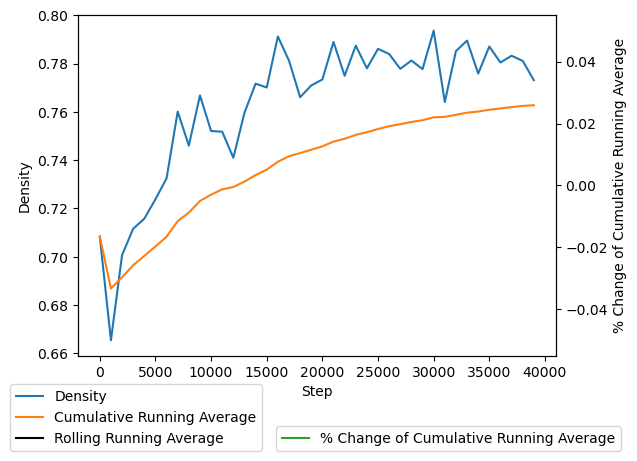

In [19]:
## test tool 4
prompt_test_4 = "Analyze the convergence of the Density in a LAMMPS log file called log.lammps. Use a tolerance of 0.1 and a window size of 50 timesteps. Save the plot as a PNG file."
agent_1_response(prompt_test_4)

In [20]:
### Test the agent using prompts

combine_prompt= "Create a LAMMPS data file for ethanol (CCO) in a cubic box of size 3 nm with a density of 0.789 g/cm3. Then, generate a LAMMPS input file for an NPT simulation at 298 K and 1 atm using the created data file. Finally, analyze the convergence of the density from the log.lammps file with a tolerance of 0.1% and a window size of 50 steps, and save the plot."

agent_1_response(combine_prompt)



> Entering new AgentExecutor chain...

Invoking: `molnum` with `{'dens': 0.789, 'mm': 46.07, 'lx': 30}`


The required number of molecules is:  278
None


> Finished chain.
